# 04 — Correlation Analysis

Correlation can help identify numerical variables that have a stronger linear relationship with the final grade **G3**. It is used here as an exploratory tool, not as proof of causation.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/student-mat.csv", sep=";")


## Correlation with final grade


In [2]:
g3_corr = df.corr(numeric_only=True)["G3"].sort_values(ascending=False)
g3_corr


G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64

### Strong relationships

Two variables stand out in this dataset: **G1** and **G2**, which are earlier grades and are strongly related to **G3**. This is expected to be useful for prediction, but it also raises an important modelling question: how well can we predict the final grade without already knowing the previous grades?


In [3]:
print("G1 vs G3:", df["G1"].corr(df["G3"]))
print("G2 vs G3:", df["G2"].corr(df["G3"]))


G1 vs G3: 0.8014679320174141
G2 vs G3: 0.9048679892693013


## Visual summary


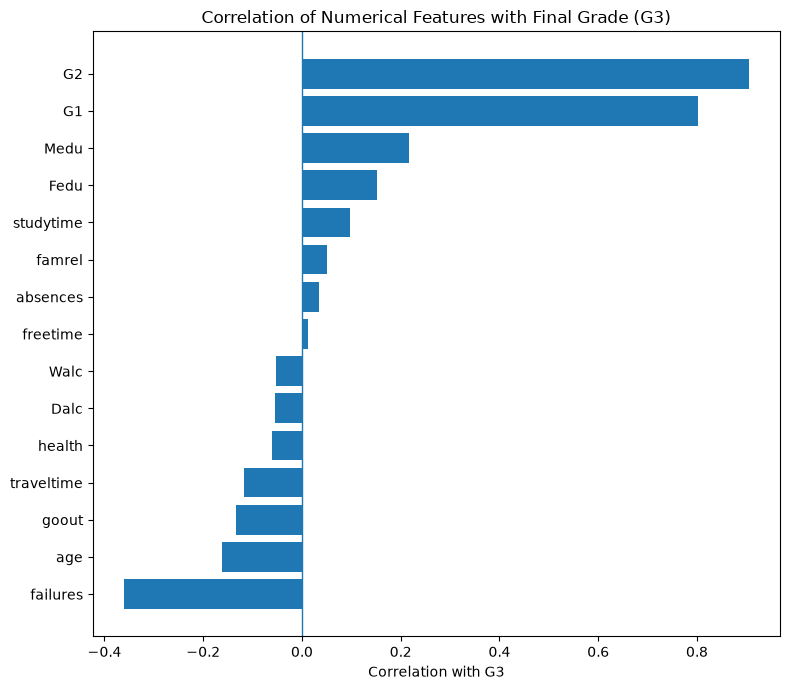

In [4]:
plot_corr = g3_corr.drop("G3").sort_values()

plt.figure(figsize=(8, 7))
plt.barh(plot_corr.index, plot_corr.values)
plt.axvline(0, linewidth=1)
plt.xlabel("Correlation with G3")
plt.title("Correlation of Numerical Features with Final Grade (G3)")
plt.tight_layout()
plt.show()


### Takeaway

The correlation analysis provides a useful reason to compare two prediction settings later: **with G1/G2** and **without G1/G2**. The second setting is more difficult, but it better represents prediction from information other than previous grades.
